# Week 4: Heston Stochastic Volatility

## Why we're here

Dupire (Week 3) fits a smile *snapshot* by letting $\sigma_{loc}(S,t)$ vary deterministically
with spot and time. It reproduces today's market prices exactly, but it gets the **dynamics**
wrong: as spot moves, Dupire's smile rolls in a direction inconsistent with what's actually
observed in markets (this was flagged from the real SPX data in Week 1, where 30 DTE skew was
observed ~70% steeper than 75 DTE, i.e. a genuine term structure, not a fixed shape). The reason
is structural: in Dupire's world $S_t$ alone is Markovian, $\sigma_{loc}$ is just a function
evaluated along whatever path $S$ takes, so there's no independent source of randomness driving
volatility itself.

Heston fixes this by giving variance its own stochastic process, correlated with spot but not
determined by it:

$$dS_t = rS_t\,dt + \sqrt{v_t}\,S_t\,dW_t^S$$
$$dv_t = \kappa(\theta - v_t)\,dt + \xi\sqrt{v_t}\,dW_t^v, \qquad dW_t^S\,dW_t^v = \rho\,dt$$

Five parameters: $v_0$ (initial variance), $\kappa$ (mean-reversion speed), $\theta$ (long-run
variance), $\xi$ (vol-of-vol), $\rho$ (spot-vol correlation, typically negative for equities,
this is what generates skew *endogenously* rather than by construction as in Dupire).

Consequence: $(S_t, v_t)$ jointly is Markovian, but $S_t$ alone is not. Feynman-Kac now gives a
PDE in three variables $(t, S, v)$ rather than Dupire's two, which is part of why this week
leans on characteristic-function pricing (Week 5) rather than a direct PDE solve.

**The known limitation to watch for going forward**: Heston is still Markovian in $(S,v)$, so
even though it fixes the *smile-dynamics* problem, it flattens the term structure of skew too
quickly at long maturities, a real but different failure mode from Dupire's. This is what
eventually motivates jumps (Week 7) and rough volatility (Week 9).

## The CIR thread (payoff)

The variance process on its own is the Cox-Ingersoll-Ross (CIR) process, flagged back on Day 7
and Day 10. Its diffusion coefficient $\xi\sqrt{v_t}$ is state-dependent: as $v_t \to 0$ the
noise shrinks and the mean-reverting drift $\kappa\theta\,dt$ dominates, which is what keeps
$v_t$ nonnegative (contrast with an OU process, constant diffusion coefficient, Gaussian at
every fixed time, can go negative, fine for rates, wrong for variance).

This state-dependence is exactly why CIR's transition density is a scaled **noncentral
chi-squared** distribution rather than Gaussian, closed form, and exact (no discretization
bias) simulation is possible directly from it.

**Feller condition**: $2\kappa\theta \geq \xi^2$ guarantees the exact continuous-time process
never touches zero. It says nothing about discrete-time approximations of it, see lessons below.

## Plan for this week

1. Euler-discretized simulator with truncation, get something running end to end
2. Diagnose and fix the negativity failure mode (see lessons learned)
3. Andersen QE scheme (better bias/speed tradeoff than truncated Euler)
4. Characteristic function derivation, sets up Week 5's Fourier pricing directly


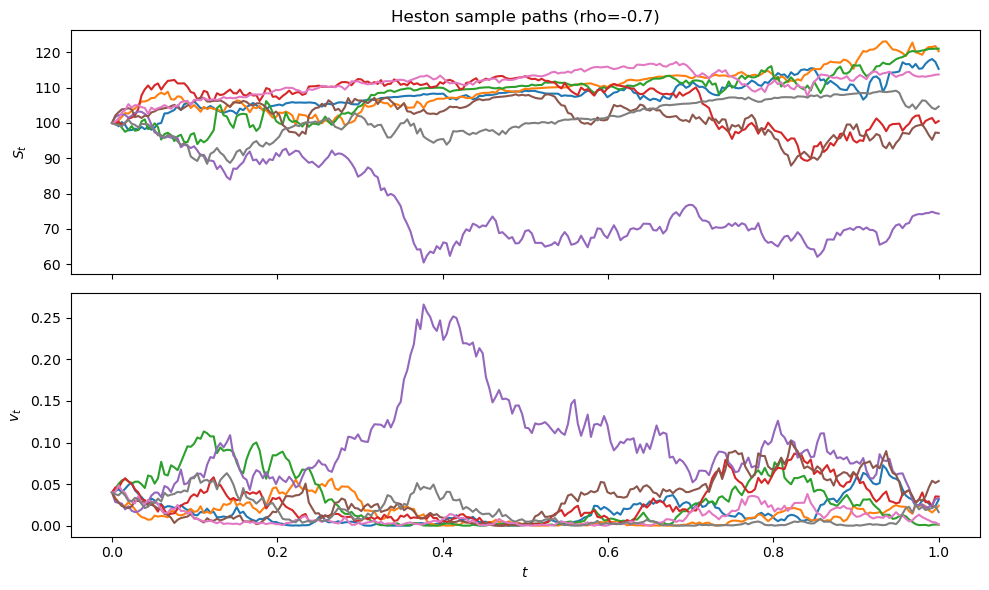

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from models.heston import sample_cir_qe_step, simulate_heston_paths

rng = np.random.default_rng(42)
S0, v0 = 100.0, 0.04
kappa, theta, xi, rho, r = 2.0, 0.04, 0.5, -0.7, 0.05
T, n_steps = 1.0, 252

S_demo, v_demo = simulate_heston_paths(S0, v0, kappa, theta, xi, rho, r,
                                         T, n_steps, n_paths=8, rng=rng)

t_grid = np.linspace(0, T, n_steps + 1)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(t_grid, S_demo.T)
axes[0].set_ylabel("$S_t$")
axes[0].set_title(f"Heston sample paths (rho={rho})")

axes[1].plot(t_grid, v_demo.T)
axes[1].set_ylabel("$v_t$")
axes[1].set_xlabel("$t$")
plt.tight_layout()
plt.show()

In [2]:
from scipy.stats import ncx2

rng = np.random.default_rng(1)
n_paths_hist = 200_000
S_h, v_h = simulate_heston_paths(S0, v0, kappa, theta, xi, rho, r,
                                   T=1.0, n_steps=252, n_paths=n_paths_hist, rng=rng)
v_T = v_h[:, -1]

dt_total = 1.0  # T itself, since v0 is the t=0 starting point
ekt = np.exp(-kappa * dt_total)
c = xi**2 * (1 - ekt) / (4 * kappa)
df = 4 * kappa * theta / xi**2
nc = 4 * kappa * ekt * v0 / (xi**2 * (1 - ekt))

x_grid = np.linspace(1e-6, v_T.max(), 500)
theoretical_pdf = ncx2.pdf(x_grid / c, df=df, nc=nc) / c

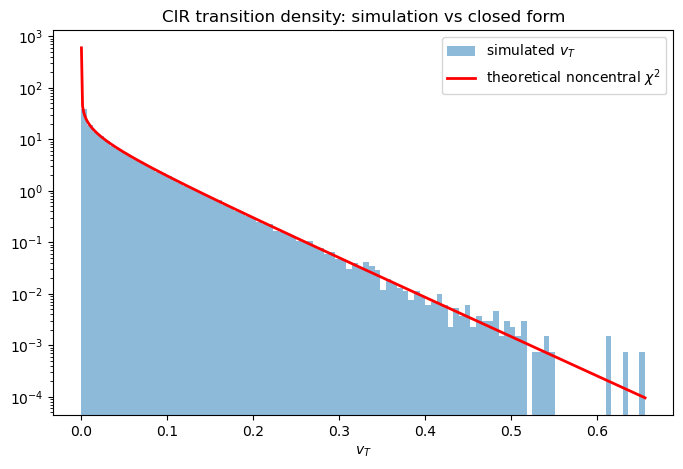

In [3]:
plt.figure(figsize=(8, 5))
plt.hist(v_T, bins=100, density=True, alpha=0.5, label="simulated $v_T$")
plt.plot(x_grid, theoretical_pdf, 'r-', lw=2, label="theoretical noncentral $\\chi^2$")
plt.xlabel("$v_T$")
plt.yscale('log')
plt.legend()
plt.title("CIR transition density: simulation vs closed form")
plt.show()

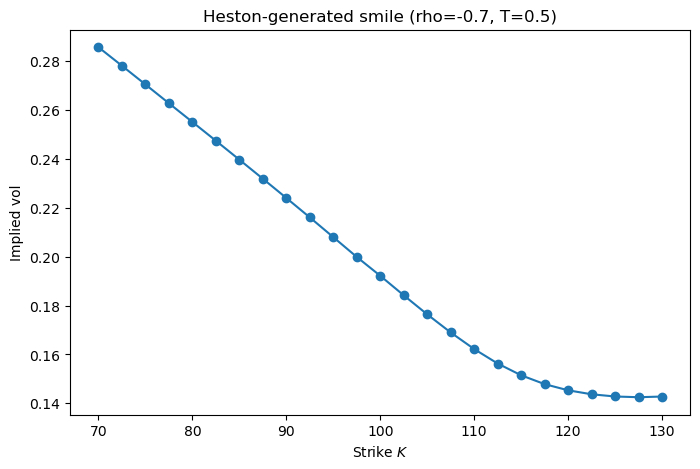

In [4]:
from calibration.implied_vol import bsm_implied_vol, compute_smile

rng = np.random.default_rng(2)
n_paths_smile = 500_000
T_smile = 0.5
S_sm, v_sm = simulate_heston_paths(S0, v0, kappa, theta, xi, rho, r,
                                     T=T_smile, n_steps=126, n_paths=n_paths_smile, rng=rng)
S_T_smile = S_sm[:, -1]

strikes = np.linspace(70, 130, 25)
ivs = np.empty_like(strikes)

for i, K in enumerate(strikes):
    if K >= S0:
        payoff = np.maximum(S_T_smile - K, 0.0)
        opt = 'call'
    else:
        payoff = np.maximum(K  - S_T_smile, 0.0)
        opt = 'put'
    price = np.exp(-r * T_smile) * payoff.mean()
    ivs[i] = bsm_implied_vol(price, S0, K, T_smile, r, option_type=opt)

plt.figure(figsize=(8, 5))
plt.plot(strikes, ivs, 'o-')
plt.xlabel("Strike $K$")
plt.ylabel("Implied vol")
plt.title(f"Heston-generated smile (rho={rho}, T={T_smile})")
plt.show()

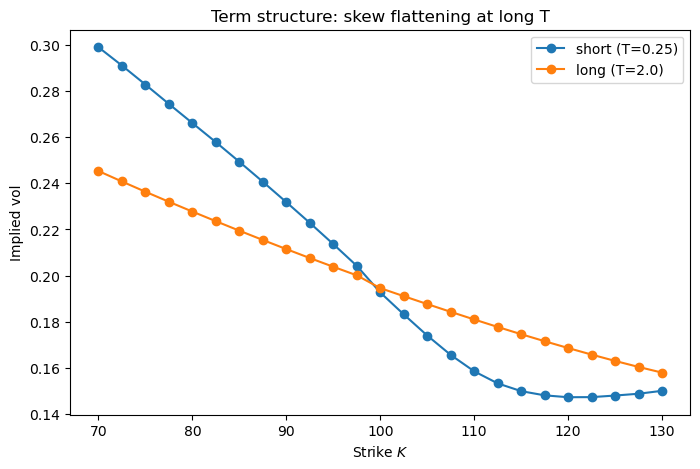

In [6]:
rng = np.random.default_rng(3)
maturities = {"short (T=0.25)": 0.25, "long (T=2.0)": 2.0}
strikes_ts = np.linspace(70, 130, 25)

plt.figure(figsize=(8, 5))
for label, T_m in maturities.items():
    n_steps_m = max(int(252 * T_m), 10)
    S_ts, _ = simulate_heston_paths(S0, v0, kappa, theta, xi, rho, r,
                                      T=T_m, n_steps=n_steps_m, n_paths=300_000, rng=rng)
    S_T_ts = S_ts[:, -1]
    ivs_ts = np.empty_like(strikes_ts)
    for i, K in enumerate(strikes_ts):
        if K >= S0:
            payoff = np.maximum(S_T_ts - K, 0.0)
            opt = 'call'
        else:
            payoff = np.maximum(K  - S_T_ts, 0.0)
            opt = 'put'
        price = np.exp(-r * T_m) * payoff.mean()
        ivs_ts[i] = bsm_implied_vol(price, S0, K, T_m, r, option_type=opt)
    plt.plot(strikes_ts, ivs_ts, 'o-', label=label)

plt.xlabel("Strike $K$")
plt.ylabel("Implied vol")
plt.legend()
plt.title("Term structure: skew flattening at long T")
plt.show()

## Lessons learned (Day 16)

- **$W_t^S$, $W_t^v$ notation**: the superscript labels which SDE a Brownian motion belongs to,
  not an exponent. Correlation $dW_t^S\,dW_t^v = \rho\,dt$ is the continuous-time quadratic
  covariation, constructible from two independent Brownians via
  $W^S = W^1$, $W^v = \rho W^1 + \sqrt{1-\rho^2}\,W^2$. This is also the Cholesky recipe for
  simulation.

- **OU vs CIR**: OU has constant diffusion coefficient $\xi$, Gaussian at every fixed time, can
  go negative. CIR's diffusion coefficient $\xi\sqrt{v_t}$ vanishes as $v_t \to 0$, which is what
  keeps the process nonnegative and is also what breaks Gaussianity, producing the noncentral
  chi-squared transition density instead.

- **Euler discretization of CIR fails structurally, not just occasionally**: the update
  $v_{t+\Delta t} = v_t + \kappa(\theta - v_t)\Delta t + \xi\sqrt{v_t}\sqrt{\Delta t}\,Z$ uses an
  unbounded Gaussian shock evaluated at the *start* of the interval. For any $\Delta t > 0$ there
  is nonzero probability $Z$ drives the update below zero, at which point the next step needs
  $\sqrt{\text{negative}}$. Feller only makes this rarer (less time spent near zero on average),
  it does not make it impossible for finite $\Delta t$, the failure mode is present regardless of
  parameters.

- **Exact simulation cost, two separate issues**:
  1. Sampling $v_{t+\Delta t}$ exactly requires a noncentral chi-squared draw: Poisson-mixture of
     central chi-squares, $N \sim \text{Poisson}(\lambda/2)$, then central $\chi^2$ with
     $d + 2N$ degrees of freedom. Real overhead per step vs. Euler's single Gaussian pull.
  2. Exact $(S_t, v_t)$ joint simulation needs more than the two variance endpoints. The spot SDE's
     noise term integrates $\sqrt{v_s}$ over the *whole step*, so exact joint simulation
     (Broadie-Kaya) requires sampling the integrated variance
     $\int_t^{t+\Delta t} v_s\,ds$ conditional on both endpoints, which has no closed-form
     distribution and is inverted numerically from its Laplace transform. This is why full
     Broadie-Kaya is rarely used in practice.

- **Decision**: Andersen QE next (moment-matched scheme approximating the true conditional
  distribution with a cheap-to-sample one), better bias/speed tradeoff than truncated Euler,
  much cheaper than full Broadie-Kaya. Implementation Day 17.


## Lessons learned (Day 17-18): Andersen QE implementation and results

### QE variance sampler (Day 17)

- **Regime switching validated in both directions.** `cir_qe_regime_params` computes
  $m$, $s^2$, $\psi = s^2/m^2$ and the regime-1 ($\psi\le\psi_c$, squared Gaussian)
  vs regime-2 ($\psi>\psi_c$, point mass + exponential) quantities once, shared by
  both `sample_cir_qe_step` and the spot-side $K_0$ correction, single source of
  truth for the moment-matching algebra.
- **$\psi\to0$ as $\Delta t\to0$, not the other way round.** Initial test parameters
  assumed a daily step could force regime 2 under a badly-Feller-violated parameter
  set; it couldn't. Leading order, $\psi \approx \xi^2\Delta t / v_t$, so *smaller*
  steps push toward regime 1 (locally everything looks Gaussian), and regime 2 is a
  genuinely finite-step phenomenon, needs large $\Delta t$ and/or small $v_t$ and/or
  large $\xi$ together, not just a Feller-violated parameter set on its own.
- **Squared-Gaussian validity boundary matches the regime cutoff.** $b^2\ge0$ in the
  regime-1 formula requires $\psi\le2$; Andersen's suggested $\psi_c\in[1,2]$ sits
  inside that domain with margin, not a coincidence, the switching rule lives inside
  the region where the high-variance formula is even real-valued.
- **Moments-only tests have a blind spot**: matching mean and variance doesn't rule
  out a regime-1/regime-2 swap bug, since two very different distributions can share
  the same first two moments. Flagged as open, not yet added (TODO below).

### Spot-side simulation and the martingale correction (Day 18)

- **Deriving $K_1, K_2$'s coefficient of $(v_{t+\Delta t}-v_t)$**: integrate the
  *variance* SDE over the step and isolate the stochastic integral
  $\xi\int\sqrt{v_s}\,dW_s^v$ as a known quantity (both endpoints plus the
  $\gamma_1 v_t+\gamma_2 v_{t+\Delta t}$ approximation to $\int v_s\,ds$ are already
  in hand from the QE step). The correlated spot noise term is $\rho\int\sqrt{v_s}\,dW_s^S
  = \rho\int\sqrt{v_s}\,dW_s^v$ (structurally, since $dW^S$ decomposes into a
  $\rho$-weighted copy of $dW^v$ plus an independent piece), so dividing by $\xi$
  gives the $\rho/\xi$ coefficient directly, no separate derivation needed once the
  variance SDE is integrated.
- **$K_0$ (martingale correction) is regime-specific** because it comes from the MGF
  of whichever approximating law generated $v_{t+\Delta t}$, evaluated at
  $s=K_2+\tfrac12 K_4$; regime 1 uses the shifted-squared-Gaussian MGF, regime 2 the
  point-mass/exponential mixture MGF. Reuses the exact same $a,b^2,p,\beta$ from the
  variance step, nothing new to compute, just a different closed-form plug-in.
- **Martingale test isolates $K_0$ specifically**: $E[S_T]=S_0e^{rT}$ is a property
  of the *spot* process alone and doesn't touch the variance-moment tests at all, so
  it's the right regression guard for a $K_0$ bug that the Day 17 tests structurally
  cannot see. Tolerance built the same way as the Day 3 MC standard-error argument,
  swap constant $\sigma$ for $\sqrt\theta$ (long-run variance stand-in, since Heston
  vol isn't constant but mean-reverts there): $\text{SE}\approx\sqrt\theta\,S_0
  e^{rT}\sqrt{T/N}$, checked against 4 SE. Passed on first correct implementation.

### Results (Day 18 notebook cells)

- **Leverage effect, visually confirmed.** With $\rho=-0.7$, the sharpest single
  path drop in $S_t$ coincides *exactly in time* (not lagged) with the largest
  variance spike in $v_t$, both driven by the same correlated shock at each step.
  Dupire cannot produce this endogenously, single Brownian motion, no independent
  vol shock to correlate against.
- **Chi-squared tail check completed (log-scale replot)**: theoretical noncentral
  $\chi^2$ tracks the simulated histogram down to ~$10^{-4}$ density, confirming
  agreement through the tail, not just near the $df<2$ singularity at $v_T=0$.
  Scatter in the far tail ($v_T\gtrsim0.35$) straddles the theoretical curve rather
  than deviating systematically, consistent with Poisson counting noise in
  low-occupancy bins rather than a real mismatch.
- **Smile sign matches $\rho$'s expected direction.** $\rho<0$ fattens the left tail
  of $S_T$ (down-moves coincide with vol spikes), producing higher IV at low strikes,
  downward-sloping put skew, same sign as the real SPX smile pulled in Week 1, now
  generated endogenously from one correlation parameter rather than fit point-by-point.
- **Term structure flattening observed directly.** Long-$T$ smile visibly flatter
  than short-$T$ smile at matched strikes, confirming in simulation the limitation
  flagged since Week 3 (motivates jumps W7, rough vol W9).
- **Deep ITM/OTM implied-vol inversion is noisy, and it's a vega problem, not a
  simulation problem.** A small kink appeared at the deepest ITM strike tested
  ($K=70$ against $S_0=100$). Vega shrinks toward zero away from ATM (Day 1), and
  since $\delta\sigma \approx \delta C/\text{vega}$ (linearising the inversion), a
  *small* vega **amplifies** ordinary MC price noise into **larger** recovered-IV
  noise, the opposite of the initial intuition that low sensitivity means low noise.
  Low vega makes the *inverse* map ill-conditioned even though the forward map looks
  stable.
- **TODO (deferred, not fixed today)**: always invert the OTM instrument at each
  strike (calls for $K>S_0$, puts for $K<S_0$, converted via parity if a
  call-equivalent price is needed downstream), rather than paying for the
  ill-conditioning with more paths. Same principle as the put-to-call parity
  conversion already flagged as a Dupire real-data TODO.

### Open TODOs carried forward

- Regime-1/regime-2 swap-bug blind spot in the QE moments-only test (add a
  fraction-of-exact-zeros check in a deep regime-2 case).
- `cir_qe_regime_params` currently called twice per step in `simulate_heston_paths`
  (once inside `sample_cir_qe_step`, once directly for $K_0$); wasteful, not
  incorrect. Candidate fix: have `sample_cir_qe_step` optionally return the regime
  diagnostics alongside `v_next`.
- Chi-squared tail check on log scale.
- OTM-instrument convention for implied-vol inversion at every strike.
